# Multi-Armed Bandit: A/B/C/D Test for Discount Strategy

## Business Question
Which discount level (5%, 10%, 15%) maximizes net revenue 
without deteriorating the guardrail metric (return rate)?

## Groups
- A: control (no discount)
- B: 5% discount
- C: 10% discount
- D: 15% discount

## Method
1. Stratified random split by 50 quantiles of winsorized revenue.
2. Simulate discount effects with diminishing returns.
3. Simulate return rate deterioration (guardrail).
4. Pairwise Welch's t-tests vs control.
5. Holm-Bonferroni correction for multiple comparisons.
6. Bootstrap 95% CI for each comparison.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
customer_df = pd.read_parquet('data/processed/customer_df.parquet')

In [3]:
customer_df.head()

,customer_id,total_revenue,num_invoices,num_items,aov,group,revenue_decile,revenue_simulated,revenue_strata,total_revenue_wins,return_rate,net_revenue
0,12346,77352.96,3,74239,25784.32000,B,9,30062.63547,49,28631.0814,0.077971,27718.622556
1,12347,4921.53,8,2967,615.19125,A,8,4921.53000,44,4921.5300,0.046398,4693.180707
2,12348,1658.40,5,2704,331.68000,A,6,1658.40000,33,1658.4000,0.120161,1459.125335
3,12349,3678.69,3,1621,1226.23000,B,8,3862.62450,42,3678.6900,0.034081,3730.984063
4,12350,294.40,1,196,294.40000,A,2,294.40000,10,294.4000,0.089171,268.148026


In [5]:
customer_df.shape

(5852, 12)

In [8]:
customer_df.dtypes

customer_id               str
total_revenue         float64
num_invoices            int64
num_items               int64
aov                   float64
group                     str
revenue_decile          int64
revenue_simulated     float64
revenue_strata          int64
total_revenue_wins    float64
return_rate           float64
net_revenue           float64
dtype: object

In [9]:
customer_df['group_abcd'] = 'A'

for strata in customer_df['revenue_strata'].unique():
    idx = customer_df[customer_df['revenue_strata'] == strata].index
    n = len(idx)
    shuffled = np.random.permutation(idx)
    customer_df.loc[shuffled[:n//4], 'group_abcd'] = 'A'
    customer_df.loc[shuffled[n//4:2*n//4], 'group_abcd'] = 'B'
    customer_df.loc[shuffled[2*n//4:3*n//4], 'group_abcd'] = 'C'
    customer_df.loc[shuffled[3*n//4:], 'group_abcd'] = 'D'

print(customer_df['group_abcd'].value_counts().sort_index())

print("\nA/A check (raw total_revenue_wins):")
for g in ['B', 'C', 'D']:
    a = customer_df[customer_df['group_abcd'] == 'A']['total_revenue_wins']
    t = customer_df[customer_df['group_abcd'] == g]['total_revenue_wins']
    stat, p = ttest_ind(a, t, equal_var=False)
    print(f"  A vs {g}: p = {p:.4f}")

group_abcd
A    1450
B    1453
C    1450
D    1499
Name: count, dtype: int64

A/A check (raw total_revenue_wins):
  A vs B: p = 0.9798
  A vs C: p = 0.9526
  A vs D: p = 0.9833


In [10]:
gross_effects = {'A': 1.00, 'B': 1.05, 'C': 1.09, 'D': 1.12}
return_effects = {'A': 1.00, 'B': 1.02, 'C': 1.05, 'D': 1.10}

customer_df['revenue_abcd'] = customer_df.apply(
    lambda r: r['total_revenue_wins'] * gross_effects[r['group_abcd']], axis=1
)
customer_df['return_rate_abcd'] = customer_df.apply(
    lambda r: r['return_rate'] * return_effects[r['group_abcd']], axis=1
)
customer_df['net_revenue_abcd'] = (
    customer_df['revenue_abcd'] * (1 - customer_df['return_rate_abcd'])
)

summary = customer_df.groupby('group_abcd').agg(
    n=('net_revenue_abcd', 'count'),
    gross_mean=('revenue_abcd', 'mean'),
    return_mean=('return_rate_abcd', 'mean'),
    net_mean=('net_revenue_abcd', 'mean'),
).round(2)

summary['net_uplift_vs_A'] = (
    (summary['net_mean'] - summary.loc['A', 'net_mean'])
    / summary.loc['A', 'net_mean']
).round(4)

print(summary)

               n  gross_mean  return_mean  net_mean  net_uplift_vs_A
group_abcd                                                          
A           1450     2269.97         0.06   2118.66           0.0000
B           1453     2387.61         0.07   2229.39           0.0523
C           1450     2464.23         0.07   2297.91           0.0846
D           1499     2545.98         0.07   2370.00           0.1186


In [11]:
control = customer_df[customer_df['group_abcd'] == 'A']['net_revenue_abcd']

comparisons = ['B', 'C', 'D']
p_values = []
diffs = []

for g in comparisons:
    treatment = customer_df[customer_df['group_abcd'] == g]['net_revenue_abcd']
    stat, p = ttest_ind(control, treatment, equal_var=False)
    p_values.append(p)
    diffs.append(treatment.mean() - control.mean())
    print(f"A vs {g}: diff = {treatment.mean() - control.mean():.2f}, p = {p:.4f}")

reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='holm')

print("\nHolm-Bonferroni adjusted:")
for g, p_raw, p_adj, rej in zip(comparisons, p_values, p_adjusted, reject):
    print(f"  A vs {g}: p_raw = {p_raw:.4f}, p_adj = {p_adj:.4f}, significant = {rej}")

A vs B: diff = 110.73, p = 0.4570
A vs C: diff = 179.25, p = 0.2342
A vs D: diff = 251.34, p = 0.0980

Holm-Bonferroni adjusted:
  A vs B: p_raw = 0.4570, p_adj = 0.4685, significant = False
  A vs C: p_raw = 0.2342, p_adj = 0.4685, significant = False
  A vs D: p_raw = 0.0980, p_adj = 0.2940, significant = False


In [12]:
def bootstrap_diff(a, b, n_iter=5000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = np.zeros(n_iter)
    for i in range(n_iter):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = sb.mean() - sa.mean()
    return diffs

results = {}
for g in comparisons:
    a = control.values
    b = customer_df[customer_df['group_abcd'] == g]['net_revenue_abcd'].values
    diffs = bootstrap_diff(a, b)
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    results[g] = {'mean': diffs.mean(), 'ci_lower': lo, 'ci_upper': hi,
                  'contains_zero': lo <= 0 <= hi}
    print(f"A vs {g}: mean = {diffs.mean():.2f}, 95% CI = [{lo:.2f}, {hi:.2f}], "
          f"contains 0: {lo <= 0 <= hi}")

A vs B: mean = 114.00, 95% CI = [-177.03, 410.09], contains 0: True
A vs C: mean = 176.99, 95% CI = [-113.34, 478.98], contains 0: True
A vs D: mean = 246.73, 95% CI = [-52.57, 546.22], contains 0: True


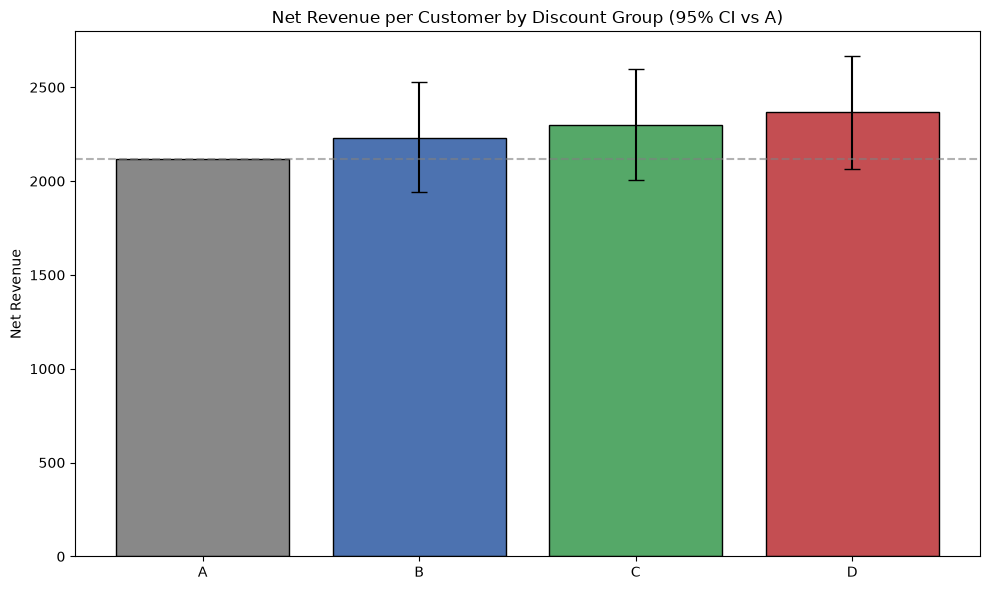

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

groups = ['A', 'B', 'C', 'D']
means = summary.loc[groups, 'net_mean'].values
colors = ['#888888', '#4C72B0', '#55A868', '#C44E52']

ax.bar(groups, means, color=colors, edgecolor='black')

base = summary.loc['A', 'net_mean']
for i, g in enumerate(['B', 'C', 'D'], start=1):
    lo = results[g]['ci_lower']
    hi = results[g]['ci_upper']
    ax.errorbar(i, means[i],
                yerr=[[means[i] - (base + lo)], [(base + hi) - means[i]]],
                fmt='none', ecolor='black', capsize=6)

ax.set_title('Net Revenue per Customer by Discount Group (95% CI vs A)')
ax.set_ylabel('Net Revenue')
ax.axhline(base, color='gray', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('abcd_net_revenue.png', dpi=120)
plt.show()

## Findings

### Point estimates
- B (5%):  +5.23% net revenue uplift vs control
- C (10%): +8.46%
- D (15%): +11.86%

### Statistical significance
- None of the discounts showed a statistically significant effect on net revenue after Holm-Bonferroni correction.
- All bootstrap 95% CIs include zero:
  - A vs B: [−177, 410]
  - A vs C: [−113, 479]
  - A vs D: [−53, 546]

### Guardrail
- Simulated return rate increase (2–10% relative) is small in absolute terms (~0.1–0.6pp) and does not dominate the effect.

### Recommendation
- **Do not roll out any discount** based on this experiment.
- The point estimates suggest diminishing returns and rising risk, but the sample is too small (n ≈ 1450 per group) to detect effects of this magnitude.
- Power analysis from the main project: ~22,389 customers per group needed to detect a 5% effect. Here we have ~15× less.
- Next steps:
  1. Run a longer experiment on the full customer base.
  2. Focus on a single discount level (15%) to maximize power.
  3. Apply CUPED to reduce variance.
  4. Re-evaluate with real (not simulated) return-rate data.